# HCP-1200 Weight-Distance Benchmark

This notebook analyzes the Schaefer-200 weight-distance benchmark. The score is the raw signed Spearman correlation between parcel centroid Euclidean distance and FC edge weight, following the Nature Methods FC-PySPI benchmark by Liu et al. (2025) and the reference implementation in `liu_fc-pyspi/code/02_network_properties.py`. Geometry is built from the Schaefer 2018 200-parcel CIFTI dlabel in `resources/schaefer_parcellations`, fsLR coordinates from `neuromaps.datasets.fetch_fslr`, and Alexander-Bloch spin nulls from `neuromaps.nulls.alexander_bloch`. Directed matrices are summarized by upper triangle, lower triangle, and combined off-diagonal scores.

In [1]:
import importlib.util
import json
import os
from pathlib import Path

import numpy as np
import pandas as pd
import scipy.stats as stats
import yaml
from IPython.display import display
from matplotlib import pyplot as plt
from pandas.errors import EmptyDataError

from arfcexp.skarf_utils import AVAILABLE_SKARF_FUNCS
from skarf import set_cache_dir
from skarf.covariance import load_spi_config_map

pd.options.display.precision = 4

PROJECT_ROOT = Path(os.environ["PROJECT_ROOT"]).resolve()
STYLE_PATH = os.environ.get("MPL_STYLE")
if STYLE_PATH and Path(STYLE_PATH).exists():
    plt.style.use(STYLE_PATH)

RESULT_DIR = Path(
    os.environ.get(
        "WEIGHT_DISTANCE_RESULT_DIR",
        str(PROJECT_ROOT / "results/hcp_1200_weight_distance_parallel"),
    )
).resolve()
PLOT_DIR = RESULT_DIR / "figures"
PLOT_DIR.mkdir(parents=True, exist_ok=True)
FORMAT = plt.rcParams.get("savefig.format", "png")
COLOR_CYCLE = plt.rcParams["axes.prop_cycle"].by_key()["color"]

TOPK_PER_CATEGORY = 2
NULL_BAND_COLOR = "#6c757d"
BASELINE_BAND_COLOR = "#d95f02"
LAG_STYLES = {0: {"alpha": 0.9, "marker": "o"}, 1: {"alpha": 0.55, "marker": "s"}}
PYPSI_CATEGORY_ORDER = ["basic", "causal", "distance", "infotheory", "misc", "spectral", "wavelet", "unknown"]
REQUIRED_BUNDLE_FILES = (
    "combination_status.csv",
    "subject_weight_distance_scores.parquet",
    "method_weight_distance_summary.csv",
    "group_weight_distance_scores.csv",
    "parcel_centroids.csv",
    "parcel_distance_matrix.npy",
)


def require_file(path: Path) -> Path:
    if not path.exists():
        raise FileNotFoundError(f"Missing {path}. Run `just eval_hcp_1200_weight_distance` first.")
    return path


def is_complete_bundle(path: Path) -> bool:
    return all((path / name).exists() for name in REQUIRED_BUNDLE_FILES)


def find_child_bundles(root: Path) -> list[Path]:
    if not root.exists():
        return []
    return sorted(
        [
            path
            for path in root.iterdir()
            if path.is_dir() and path.name.startswith("parc-") and is_complete_bundle(path)
        ]
    )


def read_csv_or_empty(path: Path) -> pd.DataFrame:
    try:
        return pd.read_csv(path)
    except EmptyDataError:
        return pd.DataFrame()


def concat_nonempty_frames(frames: list[pd.DataFrame], sort_cols: list[str]) -> pd.DataFrame:
    valid_frames = [frame for frame in frames if not frame.empty]
    if not valid_frames:
        return pd.DataFrame()
    out = pd.concat(valid_frames, ignore_index=True)
    if sort_cols and set(sort_cols).issubset(out.columns):
        out = out.sort_values(sort_cols)
    return out.reset_index(drop=True)


def compute_aggregate_stats_fallback(scores_df: pd.DataFrame, method_summary_df: pd.DataFrame) -> dict:
    script_path = PROJECT_ROOT / "scripts" / "eval_hcp_1200_weight_distance.py"
    spec = importlib.util.spec_from_file_location("weight_distance_eval", script_path)
    if spec is None or spec.loader is None:
        raise ImportError(f"Could not import {script_path}")
    mod = importlib.util.module_from_spec(spec)
    spec.loader.exec_module(mod)
    return mod.compute_aggregate_stats(scores_df, method_summary_df)


def load_weight_distance_results(result_dir: Path) -> dict:
    if is_complete_bundle(result_dir):
        params_path = result_dir / "params.yaml"
        aggregate_path = result_dir / "aggregate_stats.json"
        centroids_path = result_dir / "parcel_centroids.csv"
        distance_path = result_dir / "parcel_distance_matrix.npy"
        params = yaml.safe_load(params_path.read_text()) if params_path.exists() else {}
        aggregate_stats = json.loads(aggregate_path.read_text()) if aggregate_path.exists() else {}
        return {
            "requested_result_dir": result_dir,
            "resolved_result_dir": result_dir,
            "bundle_mode": "direct-root-bundle",
            "child_bundle_count": 0,
            "params": params,
            "aggregate_stats": aggregate_stats,
            "status": pd.read_csv(result_dir / "combination_status.csv"),
            "subject_scores": pd.read_parquet(result_dir / "subject_weight_distance_scores.parquet"),
            "method_summary": pd.read_csv(result_dir / "method_weight_distance_summary.csv"),
            "group_scores": pd.read_csv(result_dir / "group_weight_distance_scores.csv"),
            "centroids": pd.read_csv(centroids_path),
            "distance_matrix": np.load(distance_path),
        }

    child_dirs = find_child_bundles(result_dir)
    if not child_dirs:
        required = ", ".join(REQUIRED_BUNDLE_FILES)
        raise FileNotFoundError(
            f"Could not find a complete weight-distance result bundle under {result_dir}. "
            f"Expected either root-level files [{required}] or child `parc-*` directories containing them."
        )

    params_path = result_dir / "params.yaml"
    if not params_path.exists():
        params_path = require_file(child_dirs[0] / "params.yaml")
    params = yaml.safe_load(params_path.read_text())

    status = concat_nonempty_frames(
        [read_csv_or_empty(path / "combination_status.csv") for path in child_dirs],
        ["method", "func", "lag"],
    )
    subject_scores = concat_nonempty_frames(
        [pd.read_parquet(path / "subject_weight_distance_scores.parquet") for path in child_dirs],
        ["method", "func", "lag", "sub"],
    )
    method_summary = concat_nonempty_frames(
        [read_csv_or_empty(path / "method_weight_distance_summary.csv") for path in child_dirs],
        ["method", "func", "lag"],
    )
    group_scores = concat_nonempty_frames(
        [read_csv_or_empty(path / "group_weight_distance_scores.csv") for path in child_dirs],
        ["method", "func", "lag"],
    )

    centroids_path = result_dir / "parcel_centroids.csv"
    if not centroids_path.exists():
        centroids_path = require_file(child_dirs[0] / "parcel_centroids.csv")
    distance_path = result_dir / "parcel_distance_matrix.npy"
    if not distance_path.exists():
        distance_path = require_file(child_dirs[0] / "parcel_distance_matrix.npy")

    aggregate_path = result_dir / "aggregate_stats.json"
    if aggregate_path.exists():
        aggregate_stats = json.loads(aggregate_path.read_text())
    else:
        aggregate_stats = compute_aggregate_stats_fallback(subject_scores, method_summary)
        aggregate_stats["note"] = (
            "Computed inside the notebook because the parallel result root contains only child bundles "
            "and does not include merged root-level aggregate_stats.json."
        )

    return {
        "requested_result_dir": result_dir,
        "resolved_result_dir": result_dir,
        "bundle_mode": "merged-child-bundles",
        "child_bundle_count": len(child_dirs),
        "params": params,
        "aggregate_stats": aggregate_stats,
        "status": status,
        "subject_scores": subject_scores,
        "method_summary": method_summary,
        "group_scores": group_scores,
        "centroids": pd.read_csv(centroids_path),
        "distance_matrix": np.load(distance_path),
    }


def add_iqr_band(ax, q25, q75, *, color, alpha, label):
    if np.isfinite(q25) and np.isfinite(q75):
        return ax.axvspan(q25, q75, color=color, alpha=alpha, linewidth=0, label=label, zorder=0)
    return None


def significance_prefix(row, values, baseline_values, bonferroni_factor):
    null_p = row.get("spin_null_p_two_sided_across_subjects", np.nan)
    null_sig = np.isfinite(null_p) and null_p * bonferroni_factor < 0.05
    if not null_sig:
        return "(.)"
    if len(values) > 1 and len(baseline_values) > 1:
        baseline_p = stats.mannwhitneyu(values, baseline_values, alternative="two-sided").pvalue
    else:
        baseline_p = np.nan
    baseline_sig = np.isfinite(baseline_p) and baseline_p * bonferroni_factor < 0.05
    if not baseline_sig:
        return "(~)"
    return "(<)" if np.nanmedian(values) < np.nanmedian(baseline_values) else "(>)"


def values_for_combo(scores_df, combo_key, score_col="weight_distance_score"):
    return scores_df.loc[scores_df["combo_key"] == combo_key, score_col].dropna().to_numpy(dtype=float)


def display_func_name(func):
    return func.replace("cov_", "cov:").replace("prec_", "prec:").replace("linear_", "lin:")


print("PROJECT_ROOT:", PROJECT_ROOT)
print("RESULT_DIR:", RESULT_DIR)
print("PLOT_DIR:", PLOT_DIR)

PROJECT_ROOT: /home/aerkent/skarf-experiments
RESULT_DIR: /home/aerkent/skarf-experiments/results/hcp_1200_weight_distance_parallel
PLOT_DIR: /home/aerkent/skarf-experiments/results/hcp_1200_weight_distance_parallel/figures


## Load Benchmark Outputs

The root bundle is produced by `scripts/eval_hcp_1200_weight_distance_parallel.py`. It contains subject-level scores, method summaries, group-mean scores, geometry files, and the run metadata used below.

In [2]:
bundle = load_weight_distance_results(RESULT_DIR)
params = bundle["params"]
aggregate_stats = bundle["aggregate_stats"]
status = bundle["status"]
subject_scores = bundle["subject_scores"]
method_summary = bundle["method_summary"]
group_scores = bundle["group_scores"]
centroids = bundle["centroids"]
distance_matrix = bundle["distance_matrix"]

print("Requested result dir:", bundle["requested_result_dir"])
print("Resolved result dir:", bundle["resolved_result_dir"])
print("Bundle mode:", bundle["bundle_mode"])
if bundle["child_bundle_count"]:
    print("Child bundles loaded:", bundle["child_bundle_count"])
print("Parameters:")
display(pd.Series(params))
print("Status counts:")
display(status.groupby(["method", "status"], as_index=False).size())
print("Subject score rows:", len(subject_scores))
print("Method summary rows:", len(method_summary))
print("Distance matrix shape:", distance_matrix.shape)
print("Centroid table rows:", len(centroids))

Requested result dir: /home/aerkent/skarf-experiments/results/hcp_1200_weight_distance_parallel
Resolved result dir: /home/aerkent/skarf-experiments/results/hcp_1200_weight_distance_parallel
Bundle mode: merged-child-bundles
Child bundles loaded: 171
Parameters:


data_path                 /srv/projects/skarf/data_aggregation/hcp_1200_...
parc_size                                                               200
include_skarf_lag1                                                     True
min_valid_sub_fraction                                                  0.9
n_subjects                                                             None
max_combos                                                             None
seed                                                                   2142
n_perm                                                                 1000
density                                                                 32k
distance_surface                                               midthickness
n_jobs_parallel                                                           8
threads_per_worker                                                        2
method_func_list          /home/aerkent/skarf-experiments/resources/spar...
degenerate_l

Status counts:


,method,status,size
0,pyspi,insufficient_data,1
1,pyspi,ok,146
2,skarf,ok,24


Subject score rows: 147390
Method summary rows: 170
Distance matrix shape: (200, 200)
Centroid table rows: 200


## PySPI And skarf Metadata

PySPI categories are derived from the SPI config metadata via `load_spi_config_map`, and skarf estimators use the canonical order in `AVAILABLE_SKARF_FUNCS`.

In [3]:
spi_list_dir = PROJECT_ROOT / "resources/spi_lists"
set_cache_dir(spi_list_dir)
spi_config_map, _ = load_spi_config_map()

pyspi_meta_rows = []
for func in method_summary.loc[method_summary["method"] == "pyspi", "func"].dropna().unique():
    config = spi_config_map.get(func, {})
    module_name = config.get("module_name", "unknown")
    category_broad = module_name.split(".")[-1] if module_name != "unknown" else "unknown"
    if "wavelet" in func.lower():
        category_broad = "wavelet"
    category_narrow = func.split("_", 1)[0] if "_" in func else func
    pyspi_meta_rows.append(
        {
            "func": func,
            "module_name": module_name,
            "category_broad": category_broad,
            "category_narrow": category_narrow,
        }
    )
pyspi_meta = pd.DataFrame(pyspi_meta_rows)
if len(pyspi_meta) > 0:
    category_levels = [cat for cat in PYPSI_CATEGORY_ORDER if cat in set(pyspi_meta["category_broad"])]
    category_levels += sorted(set(pyspi_meta["category_broad"]) - set(category_levels))
    pyspi_meta["category_broad"] = pd.Categorical(
        pyspi_meta["category_broad"], categories=category_levels, ordered=True
    )
else:
    category_levels = []

pyspi_category_colors = {cat: COLOR_CYCLE[ii % len(COLOR_CYCLE)] for ii, cat in enumerate(category_levels)}
skarf_order = [func for func in AVAILABLE_SKARF_FUNCS if func in set(method_summary["func"])]

print("PySPI categories:")
category_counts = pyspi_meta.groupby("category_broad", observed=True).size()
category_counts.name = "n_funcs"
display(category_counts)
print("skarf order:")
print(skarf_order)

[INFO 26-05-04 10:41:09]: Loading SPI config map from cache: /home/aerkent/skarf-experiments/resources/spi_lists/spi_config_map_all.yaml


PySPI categories:


category_broad
basic         19
causal         1
distance      14
infotheory    13
misc          21
spectral      72
wavelet        6
Name: n_funcs, dtype: int64

skarf order:
['cov_empirical', 'cov_graphicallasso', 'prec_empirical', 'prec_graphicallasso', 'linear_ols', 'linear_ridge', 'linear_lasso', 'linear_enet', 'linear_lasso-pos', 'linear_enet-pos', 'linear_pls', 'linear_pca-ridge']


In [4]:
summary = method_summary.copy()
summary["score_abs"] = summary["score_mean"].abs()

empirical_key = "pyspi__cov_EmpiricalCovariance"
baseline_values = values_for_combo(subject_scores, empirical_key)
baseline_q25, baseline_q75 = (np.nan, np.nan)
if len(baseline_values) > 0:
    baseline_q25, baseline_q75 = np.nanpercentile(baseline_values, [25, 75])

empirical_row = summary.loc[summary["combo_key"] == empirical_key]
if len(empirical_row) > 0:
    empirical_row = empirical_row.iloc[0]
    null_q25 = empirical_row.get("spin_null_q25_across_subjects", np.nan)
    null_q75 = empirical_row.get("spin_null_q75_across_subjects", np.nan)
else:
    null_q25 = np.nan
    null_q75 = np.nan

pyspi_panel = summary.loc[summary["method"] == "pyspi"].merge(pyspi_meta, on="func", how="left")
if len(pyspi_panel) > 0:
    pyspi_panel["category_broad"] = pyspi_panel["category_broad"].cat.add_categories(["unknown"]).fillna("unknown")
    pyspi_panel = (
        pyspi_panel.sort_values(["category_broad", "score_abs"], ascending=[True, False])
        .groupby("category_broad", observed=True, group_keys=False)
        .head(TOPK_PER_CATEGORY)
        .sort_values("score_mean")
        .reset_index(drop=True)
    )
    pyspi_panel["display_label"] = [
        f"{significance_prefix(row._asdict(), values_for_combo(subject_scores, row.combo_key), baseline_values, max(len(pyspi_panel), 1))} {row.category_broad}:{row.func}"
        for row in pyspi_panel.itertuples()
    ]

skarf_panel = summary.loc[summary["method"] == "skarf"].copy()
if len(skarf_panel) > 0:
    skarf_panel["func"] = pd.Categorical(skarf_panel["func"], categories=skarf_order, ordered=True)
    skarf_panel = skarf_panel.sort_values(["func", "lag"]).reset_index(drop=True)
    skarf_panel["display_label"] = [
        f"{significance_prefix(row._asdict(), values_for_combo(subject_scores, row.combo_key), baseline_values, max(len(skarf_panel), 1))} {display_func_name(row.func)} lag {int(row.lag)}"
        for row in skarf_panel.itertuples()
    ]

print("Empirical covariance baseline IQR:", baseline_q25, baseline_q75)
print("Empirical spin-null IQR from subject summaries:", null_q25, null_q75)
display(summary[["method", "func", "lag", "score_mean", "score_q25", "score_q75"]].head())

Empirical covariance baseline IQR: -0.1906865869560468 -0.1546031567412368
Empirical spin-null IQR from subject summaries: -0.1480003023895309 -0.1152449878663819


,method,func,lag,score_mean,score_q25,score_q75
0,pyspi,bary_euclidean_max,0,-0.1641,-0.1825,-0.1449
1,pyspi,ce_gaussian,0,0.1073,0.0919,0.1243
2,pyspi,ce_kernel_W-0.5,0,0.1032,0.0865,0.1216
3,pyspi,cohmag_multitaper_max_fs-1_fmin-0-25_fmax-0-5,0,-0.0196,-0.0354,-0.0025
4,pyspi,cohmag_multitaper_max_fs-1_fmin-0_fmax-0-25,0,-0.0500,-0.0640,-0.0351


## Method Panels

The panels show subject-level mean signed Spearman scores with IQR whiskers. More negative values indicate stronger distance decay in FC weights. The orange band is the empirical covariance baseline IQR; the gray band is the empirical covariance spin-null IQR when spin summaries are available. Label prefixes follow the poster convention using ASCII markers: `(.)` not significant vs spin null, `(~)` significant vs null only, `(<)` or `(>)` significant vs both null and empirical baseline.

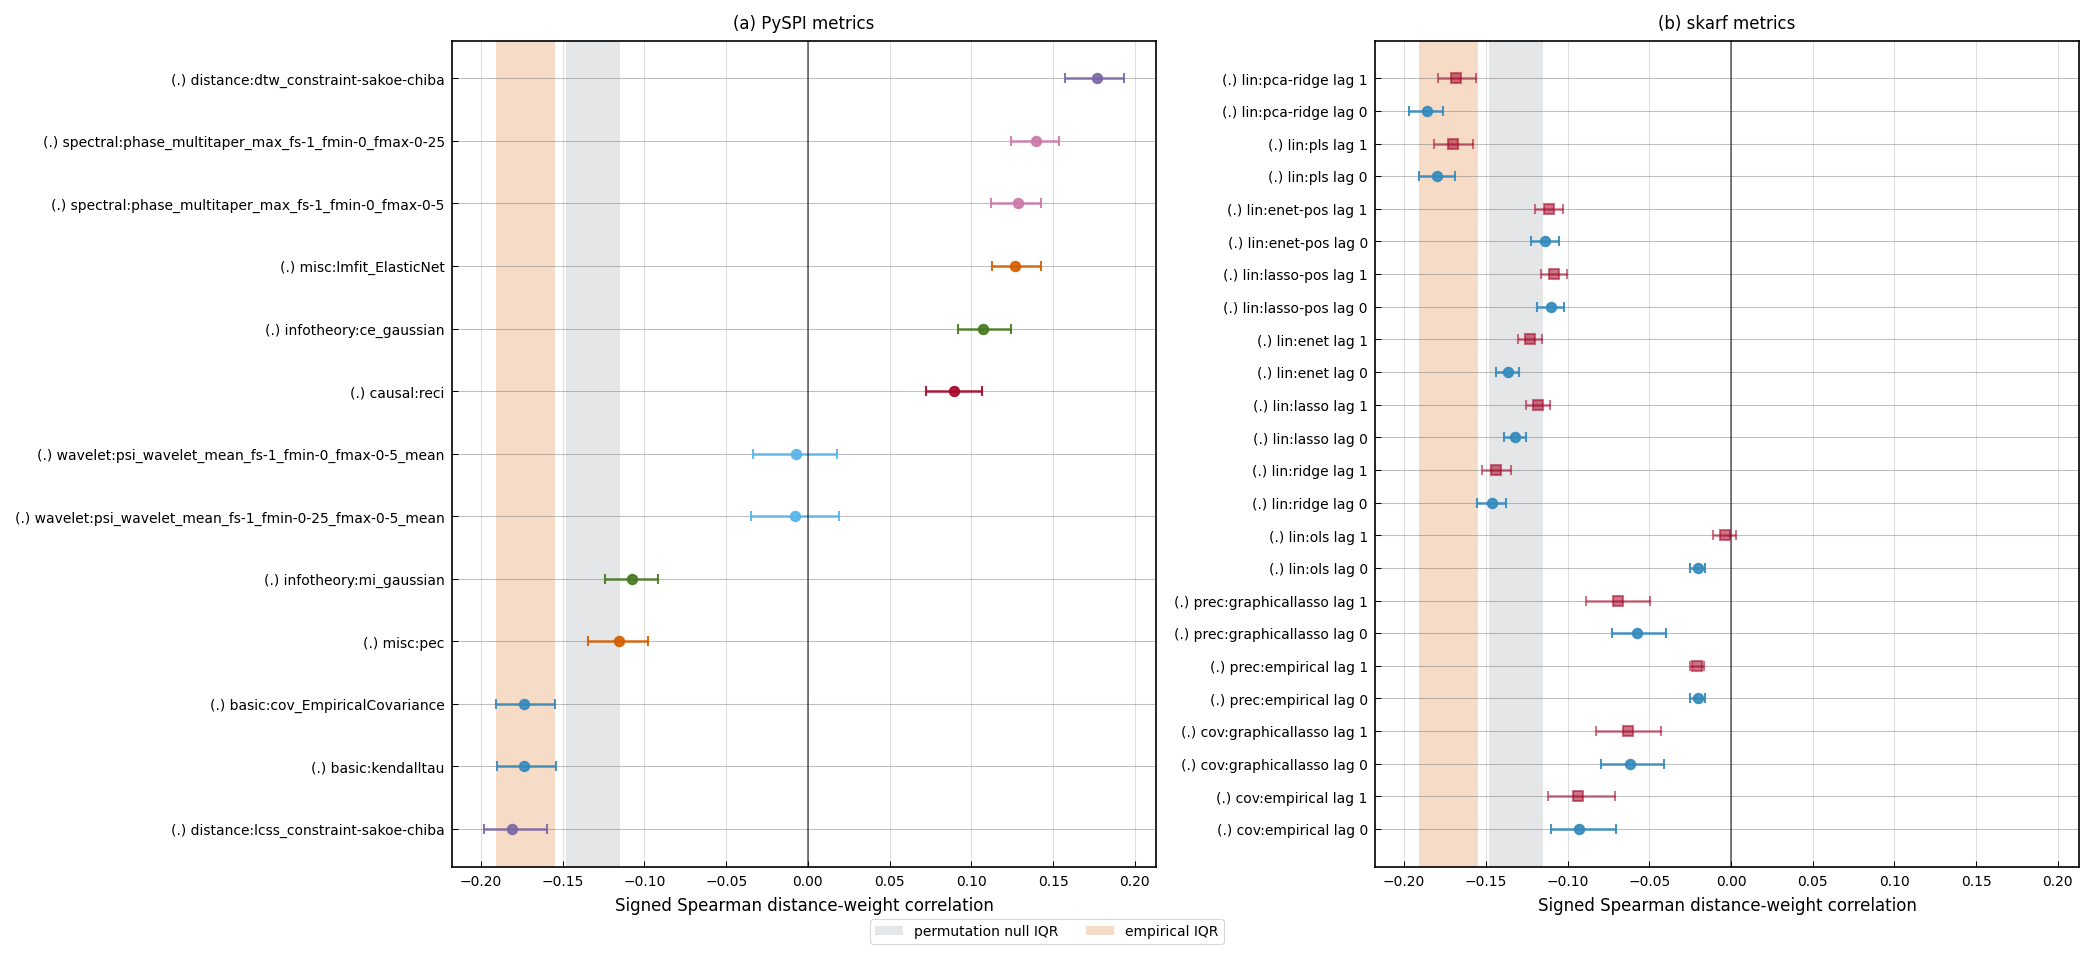

In [5]:
def plot_panel(ax, panel_df, title, color_getter):
    if len(panel_df) == 0:
        ax.text(0.5, 0.5, "No data", ha="center", va="center", transform=ax.transAxes)
        ax.set_title(title)
        return
    add_iqr_band(ax, null_q25, null_q75, color=NULL_BAND_COLOR, alpha=0.18, label="permutation null IQR")
    add_iqr_band(ax, baseline_q25, baseline_q75, color=BASELINE_BAND_COLOR, alpha=0.22, label="empirical IQR")
    y = np.arange(len(panel_df))
    for yi, row in zip(y, panel_df.itertuples()):
        q25 = getattr(row, "score_q25")
        q75 = getattr(row, "score_q75")
        mean = getattr(row, "score_mean")
        xerr = np.array([[max(mean - q25, 0)], [max(q75 - mean, 0)]])
        style = LAG_STYLES.get(int(getattr(row, "lag", 0)), LAG_STYLES[0])
        ax.errorbar(
            mean,
            yi,
            xerr=xerr,
            fmt=style["marker"],
            color=color_getter(row),
            ecolor=color_getter(row),
            elinewidth=1.2,
            capsize=2.5,
            markersize=4.5,
            alpha=style["alpha"],
            zorder=2,
        )
    ax.axvline(0, color="black", linewidth=0.8, alpha=0.6)
    ax.set_yticks(y)
    ax.set_yticklabels(panel_df["display_label"])
    ax.set_title(title)
    ax.set_xlabel("Signed Spearman distance-weight correlation")
    ax.grid(axis="x", alpha=0.25)


fig_height = max(5.5, 0.26 * max(len(pyspi_panel), len(skarf_panel), 1))
fig, axes = plt.subplots(1, 2, figsize=(14, fig_height), sharex=True)

plot_panel(
    axes[0],
    pyspi_panel,
    "(a) PySPI metrics",
    lambda row: pyspi_category_colors.get(getattr(row, "category_broad", "unknown"), "#444444"),
)
plot_panel(
    axes[1],
    skarf_panel,
    "(b) skarf metrics",
    lambda row: COLOR_CYCLE[int(getattr(row, "lag", 0)) % len(COLOR_CYCLE)],
)
handles, labels = axes[0].get_legend_handles_labels()
if handles:
    fig.legend(handles, labels, loc="lower center", ncol=len(handles), bbox_to_anchor=(0.5, -0.02))
fig.tight_layout()
fig.savefig(PLOT_DIR / f"weight_distance_method_panels.{FORMAT}", bbox_inches="tight")
plt.show()

## Group-Mean Scores

The benchmark saves both subject-level signed correlations and the signed correlation of each method's group-mean matrix. This scatter checks whether group-mean summaries track the average subject-level effect.

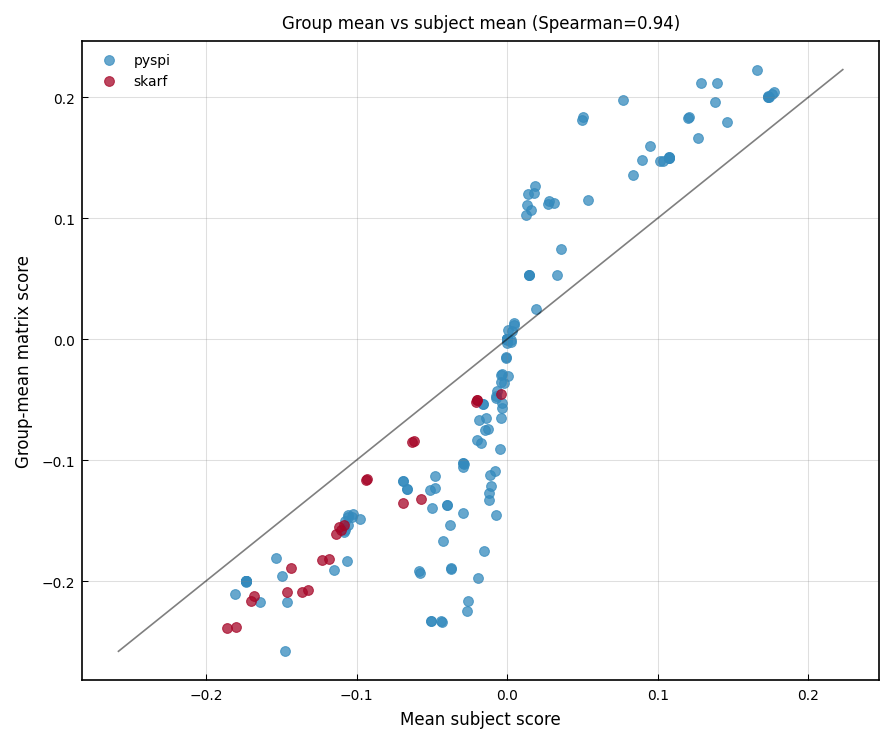

,combo_key,method,func,lag,group_weight_distance_score,score_mean
58,pyspi__lcss,pyspi,lcss,0,-0.2580,-0.1475
160,skarf__linear_pca-ridge__lag-0,skarf,linear_pca-ridge,0,-0.2386,-0.1859
162,skarf__linear_pls__lag-0,skarf,linear_pls,0,-0.2382,-0.1798
13,pyspi__coint_johansen_max_eig_stat_order-0_ard...,pyspi,coint_johansen_max_eig_stat_order-0_ardiff-10,0,-0.2334,-0.0434
17,pyspi__coint_johansen_trace_stat_order-0_ardif...,pyspi,coint_johansen_trace_stat_order-0_ardiff-10,0,-0.2333,-0.0503
15,pyspi__coint_johansen_max_eig_stat_order-1_ard...,pyspi,coint_johansen_max_eig_stat_order-1_ardiff-10,0,-0.2329,-0.0436
19,pyspi__coint_johansen_trace_stat_order-1_ardif...,pyspi,coint_johansen_trace_stat_order-1_ardiff-10,0,-0.2328,-0.0507
90,pyspi__plv_multitaper_max_fs-1_fmin-0-25_fmax-0-5,pyspi,plv_multitaper_max_fs-1_fmin-0-25_fmax-0-5,0,-0.2245,-0.0269
0,pyspi__bary_euclidean_max,pyspi,bary_euclidean_max,0,-0.2176,-0.1641
143,pyspi__xcorr_max_sig-True,pyspi,xcorr_max_sig-True,0,-0.2170,-0.1461


In [6]:
group_plot = group_scores[["combo_key", "method", "func", "lag", "weight_distance_score"]].copy()
group_plot.columns = ["combo_key", "method", "func", "lag", "group_weight_distance_score"]
group_plot = group_plot.merge(
    summary[["combo_key", "score_mean"]], on="combo_key", how="left"
)

fig, ax = plt.subplots(figsize=(6, 5))
for method, group in group_plot.groupby("method"):
    ax.scatter(group["score_mean"], group["group_weight_distance_score"], label=method, alpha=0.75, s=22)
finite = group_plot[["score_mean", "group_weight_distance_score"]].replace([np.inf, -np.inf], np.nan).dropna()
if len(finite) > 1:
    lo = float(finite.min().min())
    hi = float(finite.max().max())
    ax.plot([lo, hi], [lo, hi], color="black", linewidth=0.8, alpha=0.5)
    rho = stats.spearmanr(finite["score_mean"], finite["group_weight_distance_score"]).statistic
    ax.set_title(f"Group mean vs subject mean (Spearman={rho:.2f})")
else:
    ax.set_title("Group mean vs subject mean")
ax.set_xlabel("Mean subject score")
ax.set_ylabel("Group-mean matrix score")
ax.grid(alpha=0.25)
ax.legend(frameon=False)
fig.tight_layout()
fig.savefig(PLOT_DIR / f"weight_distance_group_vs_subject.{FORMAT}", bbox_inches="tight")
plt.show()

display(group_plot.sort_values("group_weight_distance_score").head(10))

## Directed Matrix Checks

Directed matrices are scored separately for upper and lower triangles and by all off-diagonal entries. The combined off-diagonal score is the primary directed score saved in `weight_distance_score`.

,index,method,component,count,mean,median,std
0,0,pyspi,weight_distance_score_lower,38148,0.0027,-1.6025e-03,0.0516
1,1,pyspi,weight_distance_score_offdiag,38148,0.0048,3.9031e-18,0.0476
2,2,pyspi,weight_distance_score_upper,38148,0.0069,4.0420e-03,0.0501
3,3,skarf,weight_distance_score_lower,20808,-0.1114,-1.2225e-01,0.0524
4,4,skarf,weight_distance_score_offdiag,20808,-0.1021,-1.1233e-01,0.0552
5,5,skarf,weight_distance_score_upper,20808,-0.0926,-1.0510e-01,0.0637


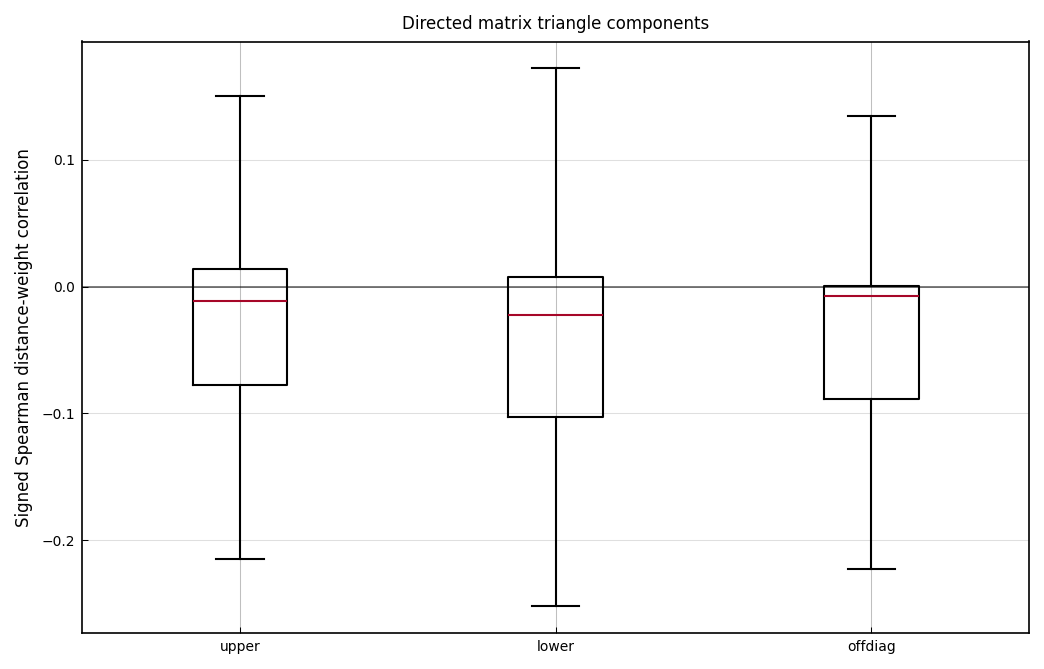

In [7]:
directed_scores = subject_scores.loc[subject_scores["is_directed"]].copy()
if len(directed_scores) == 0:
    print("No directed combinations in this result bundle.")
else:
    directed_long = directed_scores.melt(
        id_vars=["sub", "method", "func", "lag", "combo_key"],
        value_vars=["weight_distance_score_upper", "weight_distance_score_lower", "weight_distance_score_offdiag"],
        var_name="component",
        value_name="score",
    ).dropna(subset=["score"])
    component_order = ["weight_distance_score_upper", "weight_distance_score_lower", "weight_distance_score_offdiag"]
    directed_summary = (
        directed_long.groupby(["method", "component"], as_index=False)["score"]
        .agg(["count", "mean", "median", "std"])
        .reset_index()
    )
    display(directed_summary)

    fig, ax = plt.subplots(figsize=(7, 4.5))
    data = [directed_long.loc[directed_long["component"] == component, "score"].dropna() for component in component_order]
    ax.boxplot(data, tick_labels=["upper", "lower", "offdiag"], showfliers=False)
    ax.axhline(0, color="black", linewidth=0.8, alpha=0.6)
    ax.set_ylabel("Signed Spearman distance-weight correlation")
    ax.set_title("Directed matrix triangle components")
    ax.grid(axis="y", alpha=0.25)
    fig.tight_layout()
    fig.savefig(PLOT_DIR / f"weight_distance_directed_components.{FORMAT}", bbox_inches="tight")
    plt.show()

## Null And Aggregate Summaries

Spin-null p-values and z-scores are computed from the cached Alexander-Bloch parcel remappings. With `n_perm=0`, these columns are intentionally empty.

In [8]:
null_cols = [
    "method",
    "func",
    "lag",
    "score_mean",
    "spin_null_mean_across_subjects",
    "spin_null_std_across_subjects",
    "spin_null_p_two_sided_across_subjects",
    "spin_null_z_across_subjects",
]
existing_null_cols = [col for col in null_cols if col in summary.columns]
null_table = summary[existing_null_cols].sort_values("score_mean")
display(null_table.head(20))

print("Aggregate stats:")
print(json.dumps(aggregate_stats, indent=2))

print("Output figures:")
for path in sorted(PLOT_DIR.glob(f"*.{FORMAT}")):
    print(path)

,method,func,lag,score_mean,spin_null_mean_across_subjects,spin_null_std_across_subjects,spin_null_p_two_sided_across_subjects,spin_null_z_across_subjects
160,skarf,linear_pca-ridge,0,-0.1859,-0.1602,0.0163,0.0786,-1.6015
59,pyspi,lcss_constraint-sakoe-chiba,0,-0.1809,-0.1309,0.0239,0.0376,-2.1341
162,skarf,linear_pls,0,-0.1798,-0.1554,0.0154,0.0786,-1.5980
57,pyspi,kendalltau,0,-0.1735,-0.1314,0.0231,0.0660,-1.8874
21,pyspi,cov_EmpiricalCovariance,0,-0.1734,-0.1321,0.0231,0.0698,-1.8594
26,pyspi,cov_ShrunkCovariance,0,-0.1734,-0.1321,0.0231,0.0698,-1.8594
25,pyspi,cov_OAS,0,-0.1734,-0.1321,0.0231,0.0698,-1.8597
23,pyspi,cov_LedoitWolf,0,-0.1734,-0.1321,0.0231,0.0698,-1.8598
131,pyspi,spearmanr,0,-0.1734,-0.1314,0.0231,0.0659,-1.8877
24,pyspi,cov_MinCovDet,0,-0.1734,-0.1322,0.0232,0.0722,-1.8440


Aggregate stats:
{
  "family_subject_test": {
    "n": 867,
    "wilcoxon_stat": 0.0,
    "pvalue": 1.6339286643398067e-143,
    "mean_pyspi": -0.00877951222526926,
    "mean_skarf": -0.10209144462338376,
    "mean_diff_pyspi_minus_skarf": 0.0933119323981145,
    "cohen_dz": 8.971224595989725
  },
  "method_distribution_test": {
    "n_pyspi": 146,
    "n_skarf": 24,
    "mannwhitney_u": 2947.0,
    "pvalue": 9.011183830348656e-08,
    "mean_pyspi": -0.008779512225269253,
    "mean_skarf": -0.10209144462338371,
    "cohen_d": 1.1620104973385528,
    "cliffs_delta": 0.6820776255707762
  },
  "skarf_lag_test": {
    "n": 12,
    "wilcoxon_stat": 14.0,
    "pvalue": 0.05224609375,
    "mean_lag0": -0.10478922568592634,
    "mean_lag1": -0.09939366356084108,
    "mean_diff_lag0_minus_lag1": -0.005395562125085243,
    "cohen_dz": -0.6130474142209237
  },
  "note": "Computed inside the notebook because the parallel result root contains only child bundles and does not include merged root-leve

Saved poster-style weight-distance panels to /home/aerkent/skarf-experiments/results/hcp_1200_weight_distance_parallel/figures/weight_distance_poster_style_panels.png/.pdf


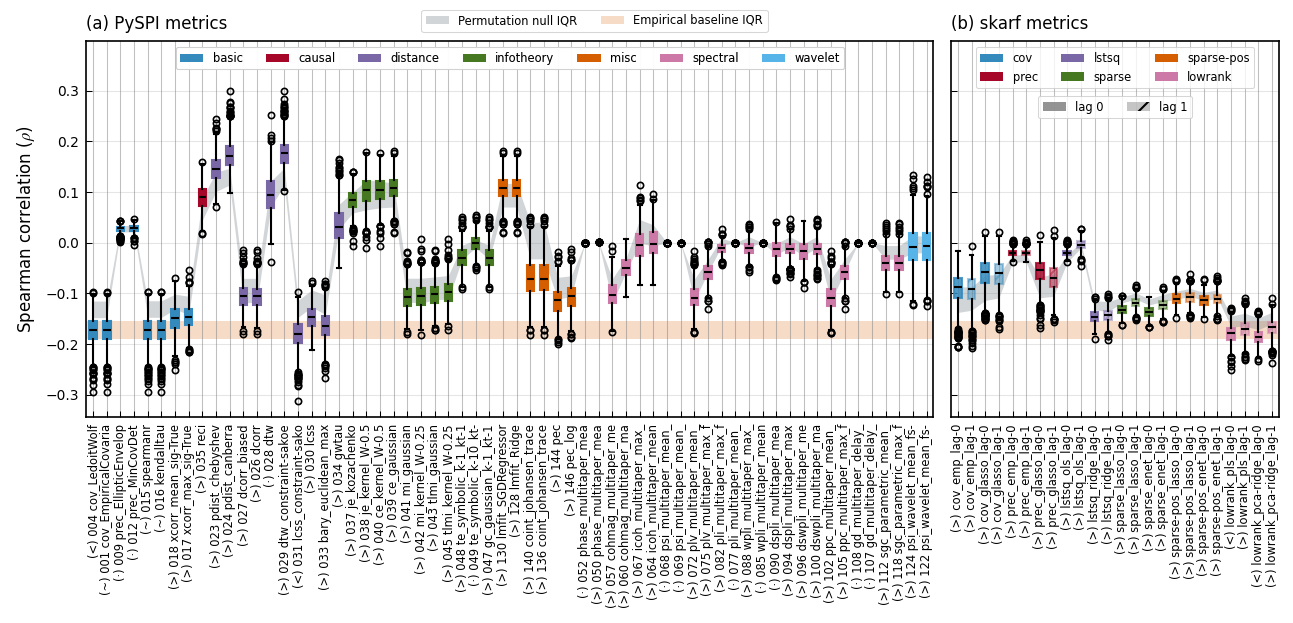

In [14]:
from matplotlib import patches as mpatches

PLOTW, _ = plt.rcParams["figure.figsize"]
LAG_ORDER = [0, 1]
lag_styles = {0: {"alpha": 0.85, "hatch": ""}, 1: {"alpha": 0.45, "hatch": "//"}}
NULL_BAND_ALPHA = 0.30
BASELINE_BAND_ALPHA = 0.22
score_col = "weight_distance_score"


def add_iqr_band_y(ax, q25, q75, color, alpha=0.2, label=None, zorder=0.1):
    if not (np.isfinite(q25) and np.isfinite(q75)):
        return None
    span = ax.axhspan(q25, q75, color=color, alpha=alpha, zorder=zorder, linewidth=0)
    if label:
        span.set_label(label)
    return span


def add_estimator_null_band(ax, positions, q25, q75, color, alpha, label=None, zorder=0.12):
    finite = np.isfinite(q25) & np.isfinite(q75)
    if not np.any(finite):
        return None
    return ax.fill_between(
        positions[finite],
        q25[finite],
        q75[finite],
        color=color,
        alpha=alpha,
        zorder=zorder,
        linewidth=0,
        label=label,
    )


def get_significance(pvalue):
    if pvalue < 0.001:
        return 3
    if pvalue < 0.01:
        return 2
    if pvalue < 0.05:
        return 1
    return 0


def safe_wilcoxon(x, y, alternative):
    x = np.asarray(x, dtype=np.float64)
    y = np.asarray(y, dtype=np.float64)
    finite = np.isfinite(x) & np.isfinite(y)
    x = x[finite]
    y = y[finite]
    if len(x) == 0:
        return np.nan
    diff = x - y
    if np.allclose(diff, 0.0):
        return 1.0
    try:
        return float(stats.wilcoxon(x, y, alternative=alternative, zero_method="pratt").pvalue)
    except ValueError:
        return np.nan


def format_weight_distance_label(base_label, values, null_p, baseline_p, bonferroni_factor, baseline_score):
    values = np.asarray(values, dtype=np.float64)
    values = values[np.isfinite(values)]
    null_sig = get_significance(null_p * bonferroni_factor) if np.isfinite(null_p) else 0
    if not null_sig:
        prefix = "(·)"
    else:
        baseline_sig = get_significance(baseline_p * bonferroni_factor) if np.isfinite(baseline_p) else 0
        if baseline_sig:
            prefix = "(<)" if np.median(values) < baseline_score else "(>)"
        else:
            prefix = "(~)"
    return f"{prefix} {base_label}"


required_cols = {"sub", "method", "func", "lag", score_col}
if not required_cols.issubset(subject_scores.columns):
    missing = sorted(required_cols.difference(subject_scores.columns))
    raise KeyError(f"subject_scores is missing required columns: {missing}")

plot_df = subject_scores.dropna(subset=[score_col]).copy()
plot_df["func"] = plot_df["func"].astype(str)
plot_df["lag"] = plot_df["lag"].fillna(0).astype(int)
if len(plot_df) == 0:
    raise ValueError("No non-null weight-distance scores available for poster-style plotting.")

null_center_col = next(
    (col for col in ["spin_null_q50", "spin_null_mean"] if col in plot_df.columns),
    None,
)
if null_center_col is None:
    raise KeyError(
        "subject_scores is missing both `spin_null_q50` and `spin_null_mean`, so subject-level null comparisons cannot be computed."
    )

summary_df = method_summary.copy()
summary_df["func"] = summary_df["func"].astype(str)
summary_df["lag"] = summary_df["lag"].fillna(0).astype(int)
summary_df = summary_df.drop_duplicates(subset=["method", "func", "lag"], keep="last")
summary_lookup = summary_df.set_index(["method", "func", "lag"])
spin_null_cols = {"spin_null_q25_across_subjects", "spin_null_q75_across_subjects"}
has_spin_null_summary = spin_null_cols.issubset(summary_df.columns)

baseline_method = "pyspi"
baseline_func = "cov_EmpiricalCovariance"
baseline_lag = 0
baseline_mask = (
    (plot_df["method"] == baseline_method)
    & (plot_df["func"] == baseline_func)
    & (plot_df["lag"] == baseline_lag)
)
baseline_values = plot_df.loc[baseline_mask, score_col].to_numpy(dtype=np.float64)
baseline_values = baseline_values[np.isfinite(baseline_values)]
if len(baseline_values) == 0:
    raise ValueError("Empirical covariance baseline missing for poster-style weight-distance plot.")
baseline_score = float(np.median(baseline_values))
baseline_q25, baseline_q75 = np.nanpercentile(baseline_values, [25, 75])
baseline_subject_df = (
    plot_df.loc[baseline_mask, ["sub", score_col]]
    .rename(columns={score_col: "baseline_score"})
    .dropna(subset=["baseline_score"])
)

shared_null_q25 = np.nan
shared_null_q75 = np.nan
if has_spin_null_summary and (baseline_method, baseline_func, baseline_lag) in summary_lookup.index:
    baseline_summary_row = summary_lookup.loc[(baseline_method, baseline_func, baseline_lag)]
    shared_null_q25 = float(baseline_summary_row["spin_null_q25_across_subjects"])
    shared_null_q75 = float(baseline_summary_row["spin_null_q75_across_subjects"])


def combo_subject_frame(method, func, lag):
    combo_df = plot_df.loc[
        (plot_df["method"] == method)
        & (plot_df["func"] == str(func))
        & (plot_df["lag"] == int(lag)),
        ["sub", score_col, null_center_col],
    ].copy()
    combo_df.rename(
        columns={score_col: "observed_score", null_center_col: "null_center_score"},
        inplace=True,
    )
    return combo_df


def combo_null_pvalue(method, func, lag):
    combo_df = combo_subject_frame(method, func, lag)
    return safe_wilcoxon(
        combo_df["observed_score"].to_numpy(dtype=np.float64),
        combo_df["null_center_score"].to_numpy(dtype=np.float64),
        alternative="two-sided",
    )


def combo_baseline_pvalue(method, func, lag):
    if method == baseline_method and str(func) == baseline_func and int(lag) == baseline_lag:
        return 1.0
    combo_df = combo_subject_frame(method, func, lag)[["sub", "observed_score"]]
    paired = combo_df.merge(baseline_subject_df, on="sub", how="inner")
    return safe_wilcoxon(
        paired["observed_score"].to_numpy(dtype=np.float64),
        paired["baseline_score"].to_numpy(dtype=np.float64),
        alternative="two-sided",
    )


spi_list_dir = PROJECT_ROOT / "resources/spi_lists"
set_cache_dir(spi_list_dir)
spi_config_map, _ = load_spi_config_map()
spi_list = (spi_list_dir / "spi_list_select_300s_149.txt").read_text().strip().split()
spi_id_map = {spi: idx for idx, spi in enumerate(spi_list, start=1)}

spi_rows = []
for spi in spi_list:
    config = spi_config_map.get(spi, {})
    module_name = config.get("module_name", "unknown")
    category = module_name.split(".")[-1] if module_name != "unknown" else "unknown"
    if "wavelet" in spi.lower():
        category = "wavelet"
    identifier = spi.split("_", 1)[0] if "_" in spi else spi
    spi_rows.append({"spi": spi, "category": category, "identifier": identifier})

spi_table = pd.DataFrame(spi_rows)
spi_table["spi"] = pd.Categorical(spi_table["spi"], categories=spi_list, ordered=True)
category_levels = [cat for cat in PYPSI_CATEGORY_ORDER if cat in set(spi_table["category"])]
category_levels += sorted(set(spi_table["category"]) - set(category_levels))
identifier_levels = spi_table["identifier"].drop_duplicates().tolist()
spi_table["category"] = pd.Categorical(spi_table["category"], categories=category_levels, ordered=True)
spi_table["identifier"] = pd.Categorical(spi_table["identifier"], categories=identifier_levels, ordered=True)
pyspi_category_colors = {
    category: COLOR_CYCLE[ii % len(COLOR_CYCLE)]
    for ii, category in enumerate(category_levels)
}

pyspi_df = plot_df.loc[plot_df["method"] == "pyspi"].copy()
pyspi_df = pyspi_df.rename(columns={"func": "spi"})
pyspi_df["spi"] = pd.Categorical(pyspi_df["spi"], categories=spi_list, ordered=True)
pyspi_with_meta = spi_table.merge(pyspi_df, on="spi", how="right")
pyspi_with_meta = pyspi_with_meta.dropna(subset=["spi"])
pyspi_with_meta["category"] = pd.Categorical(
    pyspi_with_meta["category"], categories=category_levels, ordered=True
)
pyspi_with_meta["identifier"] = pd.Categorical(
    pyspi_with_meta["identifier"], categories=identifier_levels, ordered=True
)

pyspi_values = (
    pyspi_with_meta.groupby(["category", "identifier", "spi"], observed=True)[score_col]
    .apply(lambda vals: vals.to_numpy(dtype=np.float64))
    .reset_index(name="values")
)
pyspi_values["values"] = pyspi_values["values"].apply(lambda arr: arr[np.isfinite(arr)])
pyspi_values["median"] = pyspi_values["values"].apply(
    lambda arr: np.median(arr) if len(arr) else np.nan
)
pyspi_values = pyspi_values.sort_values(
    ["category", "identifier", "median"],
    ascending=[True, True, True],
)
pyspi_panel_df = (
    pyspi_values.groupby(["category", "identifier"], as_index=False, group_keys=False, observed=True)
    .head(TOPK_PER_CATEGORY)
    .reset_index(drop=True)
)
if not pyspi_panel_df.empty:
    pyspi_panel_df["color"] = pyspi_panel_df["category"].map(pyspi_category_colors)
pyspi_tests = max(len(pyspi_panel_df), 1)

if not pyspi_panel_df.empty:
    pyspi_panel_df["null_pval"] = pyspi_panel_df["spi"].map(
        lambda spi: combo_null_pvalue("pyspi", str(spi), 0)
    )
    pyspi_panel_df["baseline_pval"] = pyspi_panel_df["spi"].map(
        lambda spi: combo_baseline_pvalue("pyspi", str(spi), 0)
    )
    pyspi_panel_df["base_label"] = pyspi_panel_df["spi"].map(
        lambda spi: f"{spi_id_map.get(str(spi), 0):03d} {str(spi)[:20]}"
    )
    pyspi_panel_df["plot_label"] = pyspi_panel_df.apply(
        lambda row: format_weight_distance_label(
            row["base_label"],
            row["values"],
            row["null_pval"],
            row["baseline_pval"],
            pyspi_tests,
            baseline_score,
        ),
        axis=1,
    )
else:
    pyspi_panel_df["plot_label"] = pd.Series(dtype=str)

if has_spin_null_summary:
    pyspi_null_lookup = (
        summary_df.loc[
            summary_df["method"] == "pyspi",
            ["func", "spin_null_q25_across_subjects", "spin_null_q75_across_subjects"],
        ]
        .groupby("func")[["spin_null_q25_across_subjects", "spin_null_q75_across_subjects"]]
        .median()
    )
else:
    pyspi_null_lookup = pd.DataFrame()

func_categories = {
    "cov": ["cov_empirical", "cov_graphicallasso"],
    "prec": ["prec_empirical", "prec_graphicallasso"],
    "lstsq": ["linear_ols", "linear_ridge"],
    "sparse": ["linear_lasso", "linear_enet"],
    "sparse-pos": ["linear_lasso-pos", "linear_enet-pos"],
    "lowrank": ["linear_pls", "linear_pca-ridge"],
}
func_category_map = {
    func: category for category, funcs in func_categories.items() for func in funcs
}
func_display_names = {
    "cov_empirical": "cov_emp",
    "cov_graphicallasso": "cov_glasso",
    "prec_empirical": "prec_emp",
    "prec_graphicallasso": "prec_glasso",
    "linear_ols": "lstsq_ols",
    "linear_ridge": "lstsq_ridge",
    "linear_lasso": "sparse_lasso",
    "linear_enet": "sparse_enet",
    "linear_lasso-pos": "sparse-pos_lasso",
    "linear_enet-pos": "sparse-pos_enet",
    "linear_pls": "lowrank_pls",
    "linear_pca-ridge": "lowrank_pca-ridge",
}
func_category_colors = {
    category: COLOR_CYCLE[ii % len(COLOR_CYCLE)]
    for ii, category in enumerate(func_categories.keys())
}

skarf_df = plot_df.loc[plot_df["method"] == "skarf"].copy()
skarf_values = (
    skarf_df.groupby(["func", "lag"], observed=True)[score_col]
    .apply(lambda vals: vals.to_numpy(dtype=np.float64))
    .reset_index(name="values")
)
skarf_values["values"] = skarf_values["values"].apply(lambda arr: arr[np.isfinite(arr)])
skarf_values = skarf_values[skarf_values["values"].map(len) > 0].reset_index(drop=True)
skarf_values["median"] = skarf_values["values"].apply(lambda arr: np.median(arr) if len(arr) else np.nan)
skarf_values["category"] = skarf_values["func"].map(func_category_map)
skarf_values["color"] = skarf_values["category"].map(func_category_colors)
skarf_tests = max(len(skarf_values), 1)

if not skarf_values.empty:
    skarf_values["null_pval"] = skarf_values.apply(
        lambda row: combo_null_pvalue("skarf", row["func"], row["lag"]),
        axis=1,
    )
    skarf_values["baseline_pval"] = skarf_values.apply(
        lambda row: combo_baseline_pvalue("skarf", row["func"], row["lag"]),
        axis=1,
    )
    skarf_values["base_label"] = skarf_values["func"].map(
        lambda func: func_display_names.get(func, str(func))
    )
    skarf_values["plot_label"] = skarf_values.apply(
        lambda row: format_weight_distance_label(
            row["base_label"],
            row["values"],
            row["null_pval"],
            row["baseline_pval"],
            skarf_tests,
            baseline_score,
        ),
        axis=1,
    )
else:
    skarf_values["plot_label"] = pd.Series(dtype=str)

skarf_label_map = {}
for row in skarf_values.itertuples():
    skarf_label_map[(row.func, int(row.lag))] = f"{row.plot_label}_lag-{int(row.lag)}"

skarf_func_order = [func for func in AVAILABLE_SKARF_FUNCS if func in set(skarf_values["func"])]
if has_spin_null_summary:
    skarf_null_lookup = (
        summary_df.loc[
            summary_df["method"] == "skarf",
            ["func", "lag", "spin_null_q25_across_subjects", "spin_null_q75_across_subjects"],
        ]
        .groupby(["func", "lag"])[["spin_null_q25_across_subjects", "spin_null_q75_across_subjects"]]
        .median()
    )
else:
    skarf_null_lookup = pd.DataFrame()

pyspi_count = max(len(pyspi_panel_df), 1)
skarf_count = max(len(skarf_func_order), 1)
fig, axes = plt.subplots(
    1,
    2,
    figsize=(3 * PLOTW, 0.95 * PLOTW),
    gridspec_kw={"width_ratios": [pyspi_count, skarf_count * len(LAG_ORDER)]},
    sharey=True,
)

ax = axes[0]
pyspi_positions = np.arange(len(pyspi_panel_df), dtype=np.float64)
if len(pyspi_panel_df) and not pyspi_null_lookup.empty:
    pyspi_null_q25 = np.array(
        [
            pyspi_null_lookup.loc[spi, "spin_null_q25_across_subjects"] if spi in pyspi_null_lookup.index else np.nan
            for spi in pyspi_panel_df["spi"]
        ],
        dtype=np.float64,
    )
    pyspi_null_q75 = np.array(
        [
            pyspi_null_lookup.loc[spi, "spin_null_q75_across_subjects"] if spi in pyspi_null_lookup.index else np.nan
            for spi in pyspi_panel_df["spi"]
        ],
        dtype=np.float64,
    )
    null_handle = add_estimator_null_band(
        ax,
        pyspi_positions,
        pyspi_null_q25,
        pyspi_null_q75,
        NULL_BAND_COLOR,
        NULL_BAND_ALPHA,
        label="Permutation null IQR",
    )
else:
    null_handle = add_iqr_band_y(
        ax,
        shared_null_q25,
        shared_null_q75,
        NULL_BAND_COLOR,
        NULL_BAND_ALPHA,
        label="Permutation null IQR",
    )
baseline_handle = add_iqr_band_y(
    ax,
    baseline_q25,
    baseline_q75,
    BASELINE_BAND_COLOR,
    BASELINE_BAND_ALPHA,
    label="Empirical baseline IQR",
)
if len(pyspi_panel_df):
    pyspi_box = ax.boxplot(
        pyspi_panel_df["values"].tolist(),
        positions=pyspi_positions,
        widths=0.55,
        patch_artist=True,
        medianprops={"color": "k"},
    )
    for patch, color in zip(pyspi_box["boxes"], pyspi_panel_df["color"]):
        patch.set_facecolor(color)
        patch.set_edgecolor(color)
    ax.set_xticks(pyspi_positions)
    ax.set_xticklabels(pyspi_panel_df["plot_label"], rotation=90, fontsize="x-small")
else:
    ax.set_xticks([])
ax.set_ylabel("Spearman correlation ($ρ$)", fontsize="medium")
ax.set_title("(a) PySPI metrics", loc="left", fontsize="medium")
if len(pyspi_panel_df):
    ymin, ymax = ax.get_ylim()
    ax.set_ylim(ymin, ymax + 0.1 * (ymax - ymin))
pyspi_handles = [
    mpatches.Patch(facecolor=pyspi_category_colors[category], edgecolor="none", label=str(category))
    for category in pyspi_panel_df["category"].dropna().unique()
] if len(pyspi_panel_df) else []
reference_handles = [handle for handle in [null_handle, baseline_handle] if handle is not None]
if reference_handles:
    ref_legend = ax.legend(
        handles=reference_handles,
        loc="upper center",
        bbox_to_anchor=(0.6, 1.1),
        ncol=len(reference_handles),
        fontsize="x-small",
    )
    ax.add_artist(ref_legend)
if pyspi_handles:
    cat_legend = ax.legend(
        handles=pyspi_handles,
        loc="upper center",
        ncol=max(len(pyspi_handles), 1),
        fontsize="x-small",
    )
    ax.add_artist(cat_legend)

ax = axes[1]
add_iqr_band_y(
    ax,
    baseline_q25,
    baseline_q75,
    BASELINE_BAND_COLOR,
    BASELINE_BAND_ALPHA,
)
if skarf_func_order:
    combo_positions = {}
    xtick_positions = []
    xtick_labels = []
    for func_idx, func in enumerate(skarf_func_order):
        for lag_idx, lag in enumerate(LAG_ORDER):
            pos = func_idx * len(LAG_ORDER) + lag_idx
            combo_positions[(func, lag)] = pos
            xtick_positions.append(pos)
            xtick_labels.append(
                skarf_label_map.get((func, lag), f"{func_display_names.get(func, func)}_lag-{lag}")
            )
    if not skarf_null_lookup.empty:
        skarf_null_q25 = []
        skarf_null_q75 = []
        for func in skarf_func_order:
            for lag in LAG_ORDER:
                key = (func, lag)
                if key in skarf_null_lookup.index:
                    skarf_null_q25.append(float(skarf_null_lookup.loc[key, "spin_null_q25_across_subjects"]))
                    skarf_null_q75.append(float(skarf_null_lookup.loc[key, "spin_null_q75_across_subjects"]))
                else:
                    skarf_null_q25.append(np.nan)
                    skarf_null_q75.append(np.nan)
        add_estimator_null_band(
            ax,
            np.asarray(xtick_positions, dtype=np.float64),
            np.asarray(skarf_null_q25, dtype=np.float64),
            np.asarray(skarf_null_q75, dtype=np.float64),
            NULL_BAND_COLOR,
            NULL_BAND_ALPHA,
        )
    else:
        add_iqr_band_y(
            ax,
            shared_null_q25,
            shared_null_q75,
            NULL_BAND_COLOR,
            NULL_BAND_ALPHA,
        )
    for lag in LAG_ORDER:
        lag_rows = skarf_values.loc[skarf_values["lag"] == lag].set_index("func")
        lag_positions = []
        lag_data = []
        for func in skarf_func_order:
            lag_positions.append(combo_positions[(func, lag)])
            if func in lag_rows.index:
                lag_data.append(lag_rows.loc[func, "values"])
            else:
                lag_data.append(np.array([np.nan]))
        box = ax.boxplot(
            lag_data,
            positions=lag_positions,
            widths=0.55,
            patch_artist=True,
            medianprops={"color": "k"},
        )
        for func, patch in zip(skarf_func_order, box["boxes"]):
            color = func_category_colors[func_category_map[func]]
            patch.set_facecolor(color)
            patch.set_edgecolor(color)
            patch.set_alpha(lag_styles[lag]["alpha"])
            patch.set_hatch(lag_styles[lag]["hatch"])
    ax.set_xticks(xtick_positions)
    ax.set_xticklabels(xtick_labels, rotation=90, fontsize="x-small")
else:
    add_iqr_band_y(
        ax,
        shared_null_q25,
        shared_null_q75,
        NULL_BAND_COLOR,
        NULL_BAND_ALPHA,
    )
    ax.set_xticks([])
ax.set_title("(b) skarf metrics", loc="left", fontsize="medium")
ax.set_ylim(axes[0].get_ylim())

category_handles = [
    mpatches.Patch(facecolor=color, label=str(category), edgecolor="none")
    for category, color in func_category_colors.items()
]
lag_handles = [
    mpatches.Patch(
        facecolor="gray",
        alpha=lag_styles[lag]["alpha"],
        hatch=lag_styles[lag]["hatch"],
        label=f"lag {lag}",
    )
    for lag in LAG_ORDER
]
cat_legend = ax.legend(
    handles=category_handles,
    loc="upper center",
    bbox_to_anchor=(0.5, 1),
    ncol=max(len(category_handles) // 2, 1),
    fontsize="x-small",
)
ax.add_artist(cat_legend)
ax.legend(
    handles=lag_handles,
    loc="upper center",
    bbox_to_anchor=(0.5, 0.87),
    ncol=len(lag_handles),
    fontsize="x-small",
)

for axis in axes:
    axis.grid(alpha=0.2, axis="y")

plt.subplots_adjust(wspace=0.03)

figure_base = PLOT_DIR / "weight_distance_poster_style_panels"
fig.savefig(f"{figure_base}.png", dpi=300)
fig.savefig(f"{figure_base}.pdf")
print(f"Saved poster-style weight-distance panels to {figure_base}.png/.pdf")
plt.show()